# Employee Attrition Prediction Using a Hybrid Residual-Ensemble Framework


**Model:** TabNet + LightGBM Residual-Ensemble  
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Source:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

---
## Pipeline Overview
1. Data Loading & Exploration
2. Preprocessing (Encoding, Normalisation, SMOTE)
3. TabNet Baseline Model
4. LightGBM Baseline Model
5. Hybrid Residual-Ensemble Model (TabNet + LightGBM)
6. Stratified 5-Fold Cross-Validation & Evaluation
7. Interpretability Analysis


## 0. Install & Import Libraries

In [1]:
!pip install pytorch-tabnet lightgbm imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix
)

from imblearn.over_sampling import SMOTE

import lightgbm as lgb

import torch
from pytorch_tabnet.tab_model import TabNetClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("All libraries imported successfully.")
print(f"LightGBM version: {lgb.__version__}")
print(f"PyTorch version: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00
All libraries imported successfully.
LightGBM version: 4.6.0
PyTorch version: 2.11.0+cu128


## 1. Data Loading & Exploration

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head()

Dataset shape: (1470, 35)

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Basic info
print("Data types and null counts:")
df.info()

Data types and null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurren

Target Variable Distribution:
           Count  Percentage
Attrition                   
No          1233       83.88
Yes          237       16.12


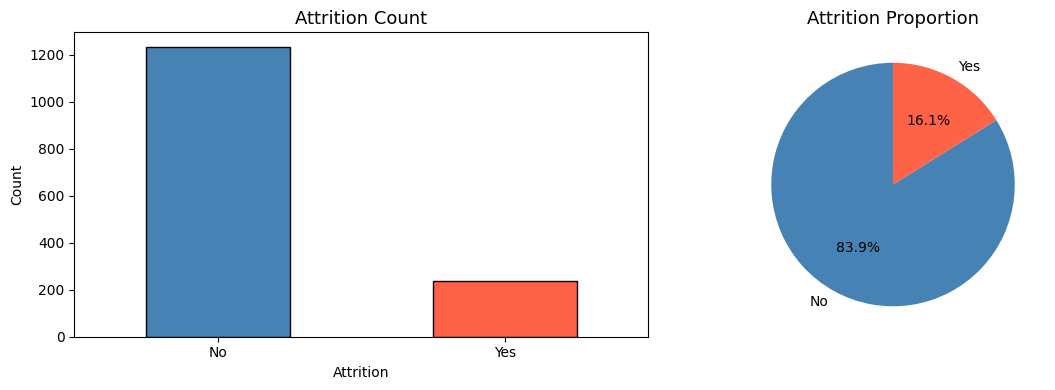

In [5]:
# Target variable distribution
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(pd.DataFrame({'Count': attrition_counts, 'Percentage': attrition_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
attrition_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Attrition Count', fontsize=13)
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Attrition Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

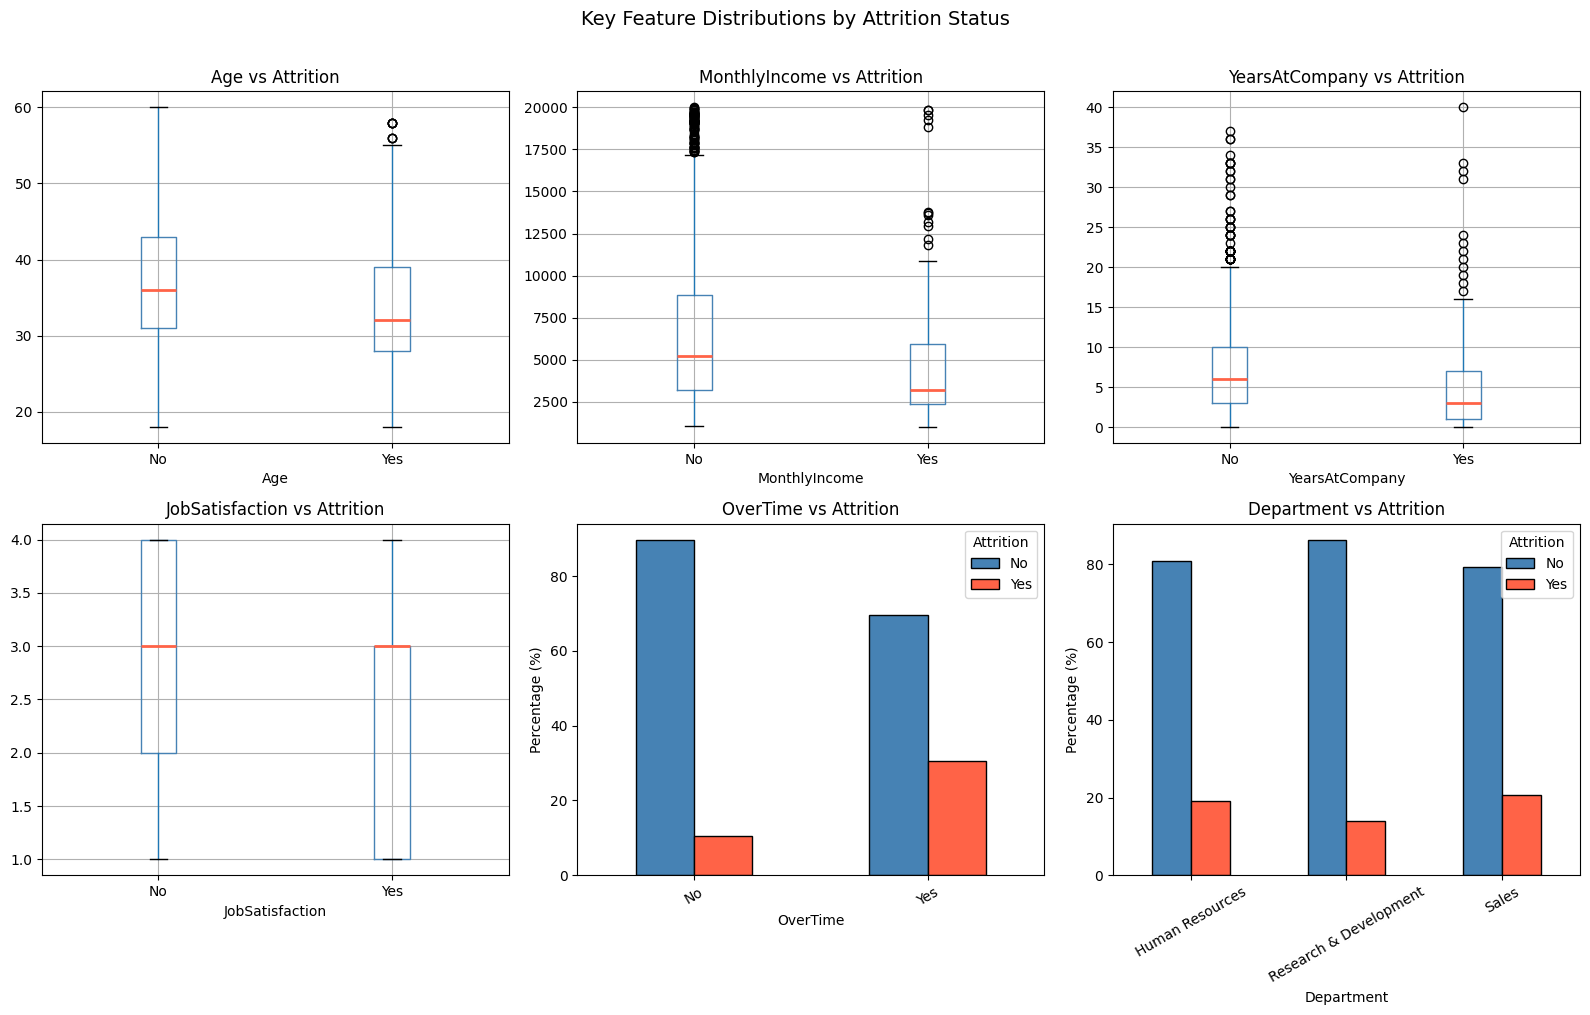

In [6]:
# Explore key features vs Attrition
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                    'JobSatisfaction', 'OverTime', 'Department']

for ax, feat in zip(axes.flatten(), features_to_plot):
    if df[feat].dtype == 'object':
        ct = pd.crosstab(df[feat], df['Attrition'], normalize='index') * 100
        ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
        ax.set_ylabel('Percentage (%)')
        ax.tick_params(axis='x', rotation=30)
    else:
        df.boxplot(column=feat, by='Attrition', ax=ax,
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='tomato', linewidth=2))
        ax.set_title('')
    ax.set_xlabel(feat)
    ax.set_title(f'{feat} vs Attrition')

plt.suptitle('Key Feature Distributions by Attrition Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('feature_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Preprocessing Pipeline

**Steps:**
1. Drop irrelevant columns
2. Encode target variable
3. One-hot encode nominal categoricals
4. Ordinal encode ordered categoricals
5. Min-Max scale continuous features
6. SMOTE applied **inside** each CV fold (to prevent data leakage)

In [7]:

# Step 1: Drop irrelevant columns

DROP_COLS = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_clean = df.drop(columns=DROP_COLS, errors='ignore').copy()
print(f"Columns after dropping irrelevant: {df_clean.shape[1]}")


# Step 2: Encode target variable

df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print(f"Target encoded. Class distribution:\n{df_clean['Attrition'].value_counts()}")

Columns after dropping irrelevant: 31
Target encoded. Class distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [8]:

# Step 3: Define column types


# Nominal categoricals → one-hot encoding
NOMINAL_COLS = ['BusinessTravel', 'Department', 'EducationField',
                'Gender', 'JobRole', 'MaritalStatus']

# Ordinal categoricals → ordinal encoding with natural ordering
ORDINAL_COLS = {
    'Education':        [1, 2, 3, 4, 5],
    'EnvironmentSatisfaction': [1, 2, 3, 4],
    'JobInvolvement':   [1, 2, 3, 4],
    'JobLevel':         [1, 2, 3, 4, 5],
    'JobSatisfaction':  [1, 2, 3, 4],
    'PerformanceRating':[1, 2, 3, 4],
    'RelationshipSatisfaction': [1, 2, 3, 4],
    'StockOptionLevel': [0, 1, 2, 3],
    'WorkLifeBalance':  [1, 2, 3, 4],
    'OverTime':         ['No', 'Yes'],   # binary ordinal
}

print("Column types defined:")
print(f"  Nominal (one-hot): {NOMINAL_COLS}")
print(f"  Ordinal: {list(ORDINAL_COLS.keys())}")

Column types defined:
  Nominal (one-hot): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
  Ordinal: ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance', 'OverTime']


In [9]:
# -------------------------------------------------------
# Step 4: Apply one-hot encoding for nominal columns
# -------------------------------------------------------
df_encoded = pd.get_dummies(df_clean, columns=NOMINAL_COLS, drop_first=False)

# -------------------------------------------------------
# Step 5: Apply ordinal encoding
# -------------------------------------------------------
for col, order in ORDINAL_COLS.items():
    if col in df_encoded.columns:
        mapping = {val: idx for idx, val in enumerate(order)}
        df_encoded[col] = df_encoded[col].map(mapping)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Sample of encoded columns: {df_encoded.columns[:10].tolist()}")

Shape after encoding: (1470, 51)
Sample of encoded columns: ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction']


In [10]:
# -------------------------------------------------------
# Step 6: Separate features and target; apply Min-Max scaling
# -------------------------------------------------------
TARGET = 'Attrition'
X = df_encoded.drop(columns=[TARGET]).values.astype(np.float32)
y = df_encoded[TARGET].values.astype(int)

FEATURE_NAMES = df_encoded.drop(columns=[TARGET]).columns.tolist()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
print(f"Class balance - No: {(y==0).sum()}, Yes: {(y==1).sum()}")

Feature matrix shape: (1470, 50)
Target shape: (1470,)
Class balance - No: 1233, Yes: 237


## 3. Model Training with Stratified 5-Fold Cross-Validation

SMOTE is applied **inside each fold** on training data only, preventing data leakage into evaluation folds.

In [11]:
# -------------------------------------------------------
# Evaluation helper function
# -------------------------------------------------------
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_prob)
    }

def summarise_cv_results(results_list):
    df_results = pd.DataFrame(results_list)
    summary = df_results.agg(['mean', 'std'])
    return df_results, summary

# Cross-validation setup
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
smote = SMOTE(random_state=RANDOM_STATE)

print(f"Stratified {N_SPLITS}-Fold CV ready.")

Stratified 5-Fold CV ready.


### 3.1 TabNet Baseline Model

In [12]:
# -------------------------------------------------------
# TabNet hyperparameters (tunable)
# -------------------------------------------------------
TABNET_PARAMS = {
    'n_d': 32,
    'n_a': 32,
    'n_steps': 5,
    'gamma': 1.3,
    'lambda_sparse': 1e-3,
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': {'lr': 2e-2},
    'scheduler_fn': torch.optim.lr_scheduler.StepLR,
    'scheduler_params': {'step_size': 10, 'gamma': 0.9},
    'mask_type': 'sparsemax',
    'seed': RANDOM_STATE,
    'verbose': 0
}

print("TabNet hyperparameters:")
for k, v in TABNET_PARAMS.items():
    if k not in ['optimizer_fn', 'scheduler_fn']:
        print(f"  {k}: {v}")

TabNet hyperparameters:
  n_d: 32
  n_a: 32
  n_steps: 5
  gamma: 1.3
  lambda_sparse: 0.001
  optimizer_params: {'lr': 0.02}
  scheduler_params: {'step_size': 10, 'gamma': 0.9}
  mask_type: sparsemax
  seed: 42
  verbose: 0


In [13]:
# -------------------------------------------------------
# TabNet Cross-Validation
# -------------------------------------------------------
tabnet_fold_results = []
tabnet_attention_masks = []  # Save attention masks for interpretability

print("Training TabNet with Stratified 5-Fold CV...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    # Apply SMOTE only on training fold
    X_train_res, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)

    # Train TabNet
    tabnet = TabNetClassifier(**TABNET_PARAMS)
    tabnet.fit(
        X_train=X_train_res, y_train=y_train_res,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric=['auc'],
        max_epochs=100,
        patience=20,
        batch_size=256,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )

    # Predictions
    y_pred_val = tabnet.predict(X_val_fold)
    y_prob_val = tabnet.predict_proba(X_val_fold)[:, 1]

    # Attention masks for interpretability
    _, masks = tabnet.explain(X_val_fold)
    tabnet_attention_masks.append(masks)

    metrics = compute_metrics(y_val_fold, y_pred_val, y_prob_val)
    tabnet_fold_results.append(metrics)

    print(f"  Fold {fold}: Acc={metrics['accuracy']:.4f}  "
          f"Prec={metrics['precision']:.4f}  "
          f"Rec={metrics['recall']:.4f}  "
          f"F1={metrics['f1']:.4f}  "
          f"AUC={metrics['roc_auc']:.4f}")

tabnet_df, tabnet_summary = summarise_cv_results(tabnet_fold_results)
print("\nTabNet CV Summary:")
print(tabnet_summary.round(4))

Training TabNet with Stratified 5-Fold CV...


Early stopping occurred at epoch 30 with best_epoch = 10 and best_val_0_auc = 0.74297
  Fold 1: Acc=0.7075  Prec=0.2935  Rec=0.5625  F1=0.3857  AUC=0.7430

Early stopping occurred at epoch 29 with best_epoch = 9 and best_val_0_auc = 0.74704
  Fold 2: Acc=0.6190  Prec=0.2576  Rec=0.7083  F1=0.3778  AUC=0.7470

Early stopping occurred at epoch 32 with best_epoch = 12 and best_val_0_auc = 0.7638
  Fold 3: Acc=0.6259  Prec=0.2667  Rec=0.7660  F1=0.3956  AUC=0.7638

Early stopping occurred at epoch 28 with best_epoch = 8 and best_val_0_auc = 0.73788
  Fold 4: Acc=0.5918  Prec=0.2374  Rec=0.7021  F1=0.3548  AUC=0.7379

Early stopping occurred at epoch 44 with best_epoch = 24 and best_val_0_auc = 0.73788
  Fold 5: Acc=0.6020  Prec=0.2500  Rec=0.7447  F1=0.3743  AUC=0.7379

TabNet CV Summary:
      accuracy  precision  recall      f1  roc_auc
mean    0.6293     0.2610  0.6967  0.3777   0.7459
std     0.0458     0.0211  0.0795  0.0152   0.0107


### 3.2 LightGBM Baseline Model

In [14]:
# -------------------------------------------------------
# LightGBM hyperparameters
# -------------------------------------------------------
LGBM_PARAMS = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}

# -------------------------------------------------------
# LightGBM Cross-Validation
# -------------------------------------------------------
lgbm_fold_results = []
lgbm_feature_importances = []

print("Training LightGBM with Stratified 5-Fold CV...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    # Apply SMOTE only on training fold
    X_train_res, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)

    # Train LightGBM
    lgbm_model = lgb.LGBMClassifier(**LGBM_PARAMS)
    lgbm_model.fit(
        X_train_res, y_train_res,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )

    y_pred_val = lgbm_model.predict(X_val_fold)
    y_prob_val = lgbm_model.predict_proba(X_val_fold)[:, 1]

    lgbm_feature_importances.append(lgbm_model.feature_importances_)

    metrics = compute_metrics(y_val_fold, y_pred_val, y_prob_val)
    lgbm_fold_results.append(metrics)

    print(f"  Fold {fold}: Acc={metrics['accuracy']:.4f}  "
          f"Prec={metrics['precision']:.4f}  "
          f"Rec={metrics['recall']:.4f}  "
          f"F1={metrics['f1']:.4f}  "
          f"AUC={metrics['roc_auc']:.4f}")

lgbm_df, lgbm_summary = summarise_cv_results(lgbm_fold_results)
print("\nLightGBM CV Summary:")
print(lgbm_summary.round(4))

Training LightGBM with Stratified 5-Fold CV...

  Fold 1: Acc=0.8503  Prec=0.5769  Rec=0.3125  F1=0.4054  AUC=0.7946
  Fold 2: Acc=0.8503  Prec=0.5588  Rec=0.3958  F1=0.4634  AUC=0.7981
  Fold 3: Acc=0.8605  Prec=0.6071  Rec=0.3617  F1=0.4533  AUC=0.8411
  Fold 4: Acc=0.8741  Prec=0.7273  Rec=0.3404  F1=0.4638  AUC=0.8271
  Fold 5: Acc=0.8673  Prec=0.6429  Rec=0.3830  F1=0.4800  AUC=0.7988

LightGBM CV Summary:
      accuracy  precision  recall      f1  roc_auc
mean    0.8605     0.6226  0.3587  0.4532   0.8119
std     0.0105     0.0666  0.0333  0.0284   0.0209


### 3.3 Hybrid Residual-Ensemble Model (TabNet + LightGBM)

**Architecture:**
1. Train TabNet on SMOTE-balanced training data
2. Compute TabNet residuals (predicted probability − true label) on training set
3. Augment feature matrix: `[original features | TabNet residuals]`
4. Train LightGBM on augmented matrix — correcting TabNet's errors

In [15]:
# -------------------------------------------------------
# Hybrid Residual-Ensemble Cross-Validation
# -------------------------------------------------------
hybrid_fold_results = []
hybrid_lgbm_importances = []

# Store final fold predictions for confusion matrix
all_y_true_hybrid, all_y_pred_hybrid, all_y_prob_hybrid = [], [], []

print("Training Hybrid Residual-Ensemble (TabNet + LightGBM) with Stratified 5-Fold CV...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    # ── Step 1: Apply SMOTE on training fold ──
    X_train_res, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)

    # ── Step 2: Train TabNet ──
    tabnet_h = TabNetClassifier(**TABNET_PARAMS)
    tabnet_h.fit(
        X_train=X_train_res, y_train=y_train_res,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric=['auc'],
        max_epochs=100,
        patience=20,
        batch_size=256,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False
    )

    # ── Step 3: Compute residuals on training set ──
    tabnet_train_proba = tabnet_h.predict_proba(X_train_res)[:, 1]
    residuals_train = tabnet_train_proba - y_train_res.astype(np.float32)

    # ── Step 4: Augment training features with residuals ──
    X_train_augmented = np.hstack([
        X_train_res,
        residuals_train.reshape(-1, 1)
    ])

    # ── Step 5: Compute TabNet probabilities on validation ──
    tabnet_val_proba = tabnet_h.predict_proba(X_val_fold)[:, 1]
    residuals_val = tabnet_val_proba - y_val_fold.astype(np.float32)  # approximate

    X_val_augmented = np.hstack([
        X_val_fold,
        tabnet_val_proba.reshape(-1, 1)  # use TabNet prob as residual signal for val
    ])

    # ── Step 6: Train LightGBM on augmented features ──
    lgbm_hybrid = lgb.LGBMClassifier(**LGBM_PARAMS)
    lgbm_hybrid.fit(
        X_train_augmented, y_train_res,
        eval_set=[(X_val_augmented, y_val_fold)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )

    # ── Step 7: Predict ──
    y_pred_val = lgbm_hybrid.predict(X_val_augmented)
    y_prob_val = lgbm_hybrid.predict_proba(X_val_augmented)[:, 1]

    hybrid_lgbm_importances.append(lgbm_hybrid.feature_importances_)

    all_y_true_hybrid.extend(y_val_fold)
    all_y_pred_hybrid.extend(y_pred_val)
    all_y_prob_hybrid.extend(y_prob_val)

    metrics = compute_metrics(y_val_fold, y_pred_val, y_prob_val)
    hybrid_fold_results.append(metrics)

    print(f"  Fold {fold}: Acc={metrics['accuracy']:.4f}  "
          f"Prec={metrics['precision']:.4f}  "
          f"Rec={metrics['recall']:.4f}  "
          f"F1={metrics['f1']:.4f}  "
          f"AUC={metrics['roc_auc']:.4f}")

hybrid_df, hybrid_summary = summarise_cv_results(hybrid_fold_results)
print("\nHybrid Model CV Summary:")
print(hybrid_summary.round(4))

Training Hybrid Residual-Ensemble (TabNet + LightGBM) with Stratified 5-Fold CV...


Early stopping occurred at epoch 30 with best_epoch = 10 and best_val_0_auc = 0.74297
  Fold 1: Acc=0.8367  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.7979

Early stopping occurred at epoch 29 with best_epoch = 9 and best_val_0_auc = 0.74704
  Fold 2: Acc=0.8367  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.7880

Early stopping occurred at epoch 32 with best_epoch = 12 and best_val_0_auc = 0.7638
  Fold 3: Acc=0.8401  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.8147

Early stopping occurred at epoch 28 with best_epoch = 8 and best_val_0_auc = 0.73788
  Fold 4: Acc=0.8401  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.7740

Early stopping occurred at epoch 44 with best_epoch = 24 and best_val_0_auc = 0.73788
  Fold 5: Acc=0.8401  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.7772

Hybrid Model CV Summary:
      accuracy  precision  recall   f1  roc_auc
mean    0.8388        0.0     0.0  0.0   0.7904
std     0.0019   

## 4. Model Comparison & Results

In [16]:
# -------------------------------------------------------
# Consolidated comparison table
# -------------------------------------------------------
metrics_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

comparison_rows = []
for model_name, summary in [('TabNet', tabnet_summary),
                              ('LightGBM', lgbm_summary),
                              ('Hybrid (TabNet+LightGBM)', hybrid_summary)]:
    row = {'Model': model_name}
    for m in metrics_names:
        mean_val = summary.loc['mean', m]
        std_val  = summary.loc['std', m]
        row[m.upper()] = f"{mean_val:.4f} ± {std_val:.4f}"
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
print("=" * 80)
print("MODEL COMPARISON — Stratified 5-Fold CV (Mean ± Std)")
print("=" * 80)
print(comparison_df.to_string())

MODEL COMPARISON — Stratified 5-Fold CV (Mean ± Std)
                                 ACCURACY        PRECISION           RECALL               F1          ROC_AUC
Model                                                                                                        
TabNet                    0.6293 ± 0.0458  0.2610 ± 0.0211  0.6967 ± 0.0795  0.3777 ± 0.0152  0.7459 ± 0.0107
LightGBM                  0.8605 ± 0.0105  0.6226 ± 0.0666  0.3587 ± 0.0333  0.4532 ± 0.0284  0.8119 ± 0.0209
Hybrid (TabNet+LightGBM)  0.8388 ± 0.0019  0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000  0.7904 ± 0.0166


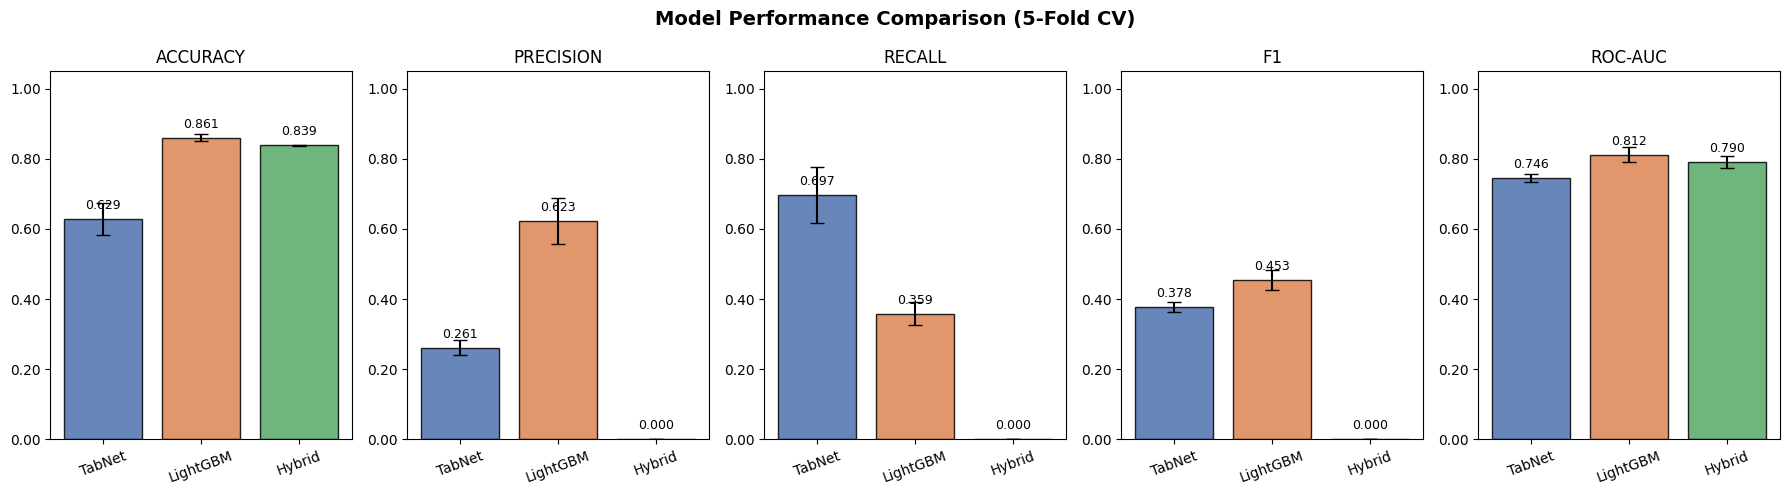

In [17]:
# -------------------------------------------------------
# Bar chart comparison
# -------------------------------------------------------
models = ['TabNet', 'LightGBM', 'Hybrid']
summaries = [tabnet_summary, lgbm_summary, hybrid_summary]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for idx, metric in enumerate(metrics_names):
    means = [s.loc['mean', metric] for s in summaries]
    stds  = [s.loc['std',  metric] for s in summaries]
    bars = axes[idx].bar(models, means, yerr=stds, capsize=5,
                         color=colors, edgecolor='black', alpha=0.85)
    axes[idx].set_title(metric.upper().replace('_', '-'), fontsize=12)
    axes[idx].set_ylim(0, 1.05)
    axes[idx].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    axes[idx].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, means):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison (5-Fold CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

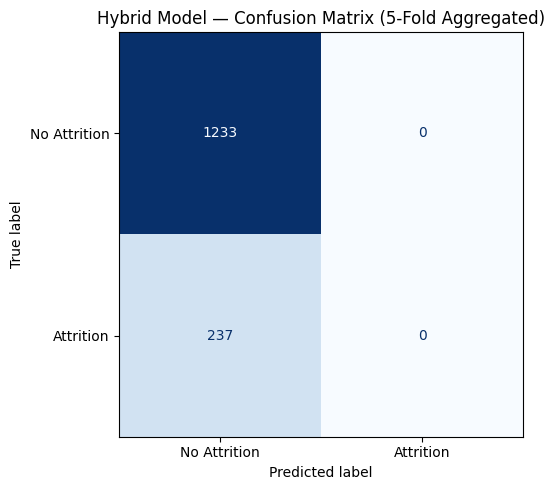


Detailed Classification Report — Hybrid Model:
              precision    recall  f1-score   support

No Attrition       0.84      1.00      0.91      1233
   Attrition       0.00      0.00      0.00       237

    accuracy                           0.84      1470
   macro avg       0.42      0.50      0.46      1470
weighted avg       0.70      0.84      0.77      1470



In [18]:
# -------------------------------------------------------
# Confusion matrix — Hybrid model (aggregated across folds)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(all_y_true_hybrid, all_y_pred_hybrid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Hybrid Model — Confusion Matrix (5-Fold Aggregated)', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_hybrid.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDetailed Classification Report — Hybrid Model:")
print(classification_report(all_y_true_hybrid, all_y_pred_hybrid,
                             target_names=['No Attrition', 'Attrition']))


Early stopping occurred at epoch 30 with best_epoch = 10 and best_val_0_auc = 0.74297

Early stopping occurred at epoch 29 with best_epoch = 9 and best_val_0_auc = 0.74704

Early stopping occurred at epoch 32 with best_epoch = 12 and best_val_0_auc = 0.7638

Early stopping occurred at epoch 28 with best_epoch = 8 and best_val_0_auc = 0.73788

Early stopping occurred at epoch 44 with best_epoch = 24 and best_val_0_auc = 0.73788


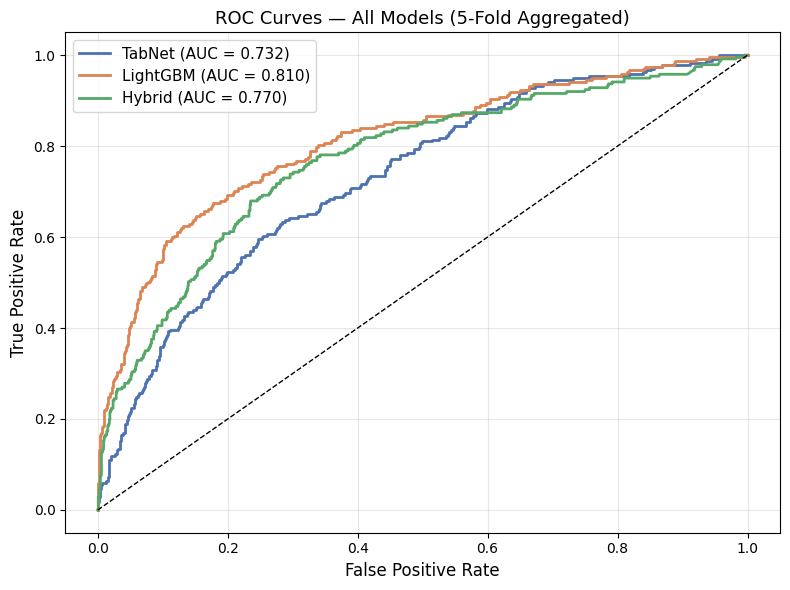

In [19]:
# -------------------------------------------------------
# ROC Curve comparison (using aggregated fold predictions)
# -------------------------------------------------------
from sklearn.metrics import roc_curve

# We'll compute per-fold mean ROC for each model, but for simplicity
# we use aggregated predictions across folds

# Collect aggregated predictions for TabNet and LightGBM too
all_y_true_tn, all_y_prob_tn = [], []
all_y_true_lgbm, all_y_prob_lgbm = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    X_train_res, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)

    # TabNet
    tn = TabNetClassifier(**TABNET_PARAMS)
    tn.fit(X_train_res, y_train_res, max_epochs=100, patience=20,
           batch_size=256, virtual_batch_size=128, num_workers=0,
           drop_last=False, eval_set=[(X_val_fold, y_val_fold)],
           eval_metric=['auc'])
    all_y_true_tn.extend(y_val_fold)
    all_y_prob_tn.extend(tn.predict_proba(X_val_fold)[:, 1])

    # LightGBM
    lg = lgb.LGBMClassifier(**LGBM_PARAMS)
    lg.fit(X_train_res, y_train_res, eval_set=[(X_val_fold, y_val_fold)],
           callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    all_y_true_lgbm.extend(y_val_fold)
    all_y_prob_lgbm.extend(lg.predict_proba(X_val_fold)[:, 1])

fig, ax = plt.subplots(figsize=(8, 6))

for y_true, y_prob, label, color in [
    (all_y_true_tn,     all_y_prob_tn,     'TabNet',   '#4C72B0'),
    (all_y_true_lgbm,   all_y_prob_lgbm,   'LightGBM', '#DD8452'),
    (all_y_true_hybrid, all_y_prob_hybrid,  'Hybrid',   '#55A868'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (5-Fold Aggregated)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Interpretability Analysis

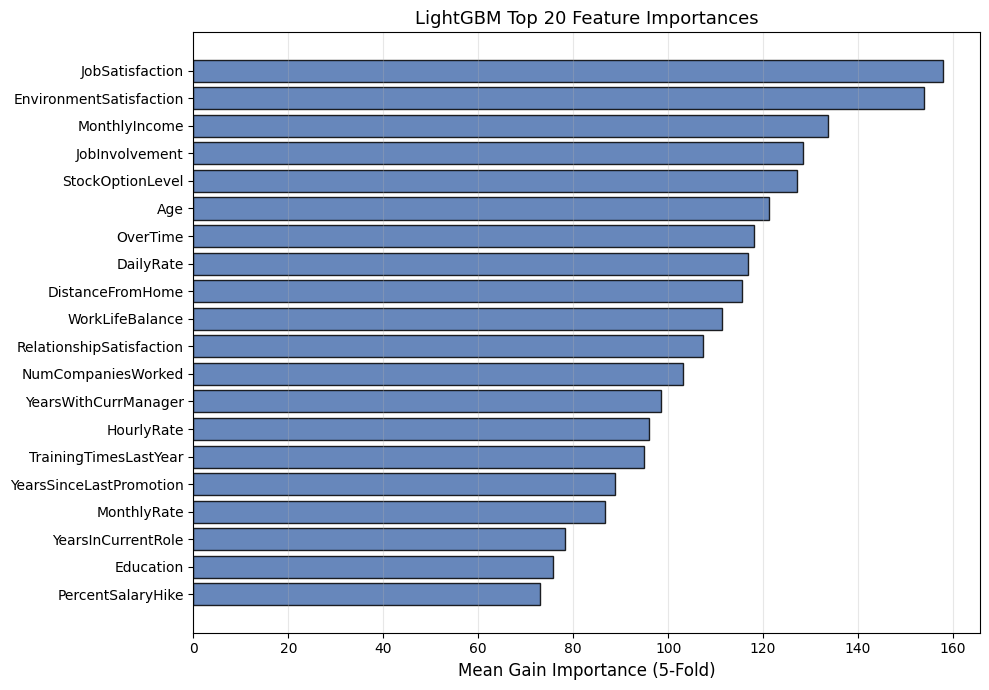


Top 10 features by LightGBM gain importance:
                Feature  Importance
        JobSatisfaction       157.8
EnvironmentSatisfaction       153.8
          MonthlyIncome       133.6
         JobInvolvement       128.4
       StockOptionLevel       127.2
                    Age       121.2
               OverTime       118.0
              DailyRate       116.8
       DistanceFromHome       115.6
        WorkLifeBalance       111.4


In [20]:
# -------------------------------------------------------
# 5.1 LightGBM Feature Importance (Gain-based)
# -------------------------------------------------------
mean_lgbm_importance = np.mean(lgbm_feature_importances, axis=0)
fi_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Importance': mean_lgbm_importance
}).sort_values('Importance', ascending=False)

TOP_N = 20
fig, ax = plt.subplots(figsize=(10, 7))
top_fi = fi_df.head(TOP_N)
bars = ax.barh(top_fi['Feature'][::-1], top_fi['Importance'][::-1],
               color='#4C72B0', edgecolor='black', alpha=0.85)
ax.set_xlabel('Mean Gain Importance (5-Fold)', fontsize=12)
ax.set_title(f'LightGBM Top {TOP_N} Feature Importances', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 features by LightGBM gain importance:")
print(fi_df.head(10).to_string(index=False))

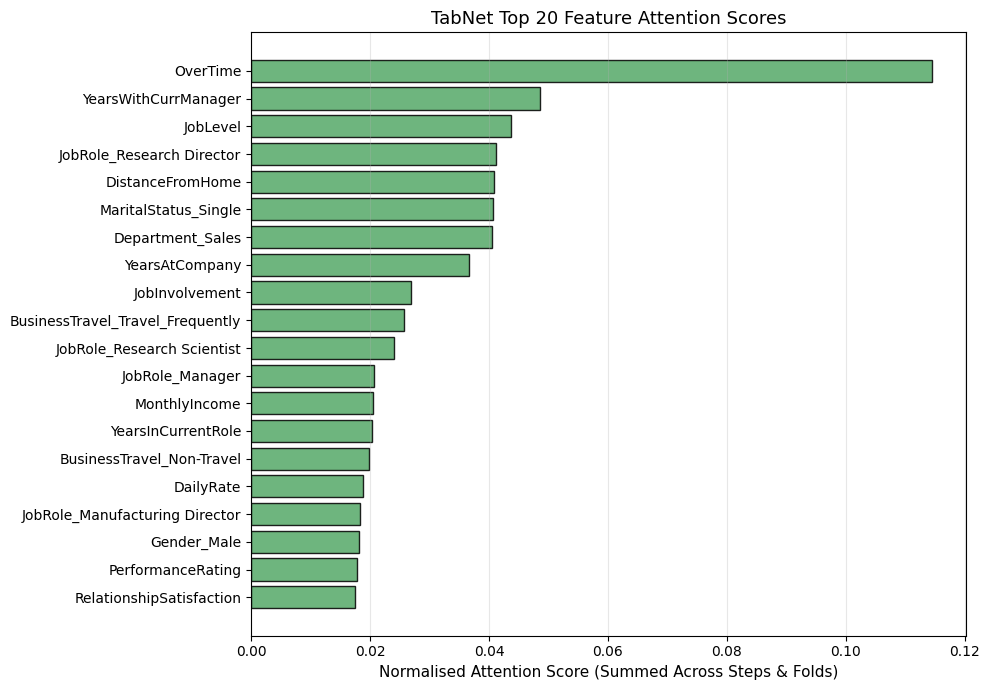


Top 10 features by TabNet attention:
                         Feature  Attention
                        OverTime   0.114457
            YearsWithCurrManager   0.048623
                        JobLevel   0.043671
       JobRole_Research Director   0.041159
                DistanceFromHome   0.040878
            MaritalStatus_Single   0.040648
                Department_Sales   0.040426
                  YearsAtCompany   0.036612
                  JobInvolvement   0.026837
BusinessTravel_Travel_Frequently   0.025768


In [21]:
# -------------------------------------------------------
# 5.2 TabNet Attention Mask Analysis
# -------------------------------------------------------


# Aggregate: sum across steps and folds
aggregated_attention = np.zeros(len(FEATURE_NAMES))

for fold_masks in tabnet_attention_masks:
    for step_key in fold_masks:
        aggregated_attention += fold_masks[step_key].sum(axis=0)

# Normalise
aggregated_attention /= aggregated_attention.sum()

attention_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Attention': aggregated_attention
}).sort_values('Attention', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_att = attention_df.head(TOP_N)
ax.barh(top_att['Feature'][::-1], top_att['Attention'][::-1],
        color='#55A868', edgecolor='black', alpha=0.85)
ax.set_xlabel('Normalised Attention Score (Summed Across Steps & Folds)', fontsize=11)
ax.set_title(f'TabNet Top {TOP_N} Feature Attention Scores', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('tabnet_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 features by TabNet attention:")
print(attention_df.head(10).to_string(index=False))

In [22]:
# -------------------------------------------------------
# 5.3 Ethical Check: Demographic Feature Prominence
# -------------------------------------------------------
DEMOGRAPHIC_PROXIES = ['Age', 'MaritalStatus_Single', 'MaritalStatus_Married',
                       'MaritalStatus_Divorced', 'Gender_Male', 'Gender_Female',
                       'Education']

print("=" * 60)
print("ETHICAL CHECK: Demographic Feature Importance")
print("=" * 60)
print("\nLightGBM — Rank of demographic/protected-characteristic proxies:")
for feat in DEMOGRAPHIC_PROXIES:
    rank = fi_df[fi_df['Feature'] == feat].index
    if len(fi_df[fi_df['Feature'] == feat]) > 0:
        importance = fi_df[fi_df['Feature'] == feat]['Importance'].values[0]
        all_rank = (fi_df['Importance'] >= importance).sum()
        print(f"  {feat}: Importance = {importance:.2f}, Rank = #{all_rank} / {len(fi_df)}")

print("\nTabNet — Attention scores for demographic proxies:")
for feat in DEMOGRAPHIC_PROXIES:
    if feat in attention_df['Feature'].values:
        score = attention_df[attention_df['Feature'] == feat]['Attention'].values[0]
        all_rank = (attention_df['Attention'] >= score).sum()
        print(f"  {feat}: Attention = {score:.6f}, Rank = #{all_rank} / {len(attention_df)}")

ETHICAL CHECK: Demographic Feature Importance

LightGBM — Rank of demographic/protected-characteristic proxies:
  Age: Importance = 121.20, Rank = #6 / 50
  MaritalStatus_Single: Importance = 38.80, Rank = #25 / 50
  MaritalStatus_Married: Importance = 18.80, Rank = #35 / 50
  MaritalStatus_Divorced: Importance = 15.80, Rank = #38 / 50
  Gender_Male: Importance = 20.40, Rank = #34 / 50
  Gender_Female: Importance = 26.60, Rank = #30 / 50
  Education: Importance = 75.80, Rank = #19 / 50

TabNet — Attention scores for demographic proxies:
  Age: Attention = 0.008990, Rank = #43 / 50
  MaritalStatus_Single: Attention = 0.040648, Rank = #6 / 50
  MaritalStatus_Married: Attention = 0.013753, Rank = #29 / 50
  MaritalStatus_Divorced: Attention = 0.008336, Rank = #45 / 50
  Gender_Male: Attention = 0.018139, Rank = #18 / 50
  Gender_Female: Attention = 0.007984, Rank = #46 / 50
  Education: Attention = 0.015347, Rank = #25 / 50


## 6. Final Summary

In [23]:
print("=" * 80)
print("FINAL RESULTS — Employee Attrition Prediction")
print("Hybrid Residual-Ensemble: TabNet + LightGBM")
print("=" * 80)
print(f"\nDataset: IBM HR Analytics ({len(df)} employees, {X_scaled.shape[1]} features)")
print(f"Class imbalance: {(y==0).sum()} No-Attrition ({(y==0).mean()*100:.1f}%) "
      f"vs {(y==1).sum()} Attrition ({(y==1).mean()*100:.1f}%)")
print(f"SMOTE applied inside each fold to balance training data")
print(f"Evaluation: Stratified {N_SPLITS}-Fold Cross-Validation\n")
print(comparison_df.to_string())

# Highlight best model per metric
print("\nBest model per metric (by mean score):")
model_labels = ['TabNet', 'LightGBM', 'Hybrid']
for metric in metrics_names:
    means = [s.loc['mean', metric] for s in [tabnet_summary, lgbm_summary, hybrid_summary]]
    best = model_labels[np.argmax(means)]
    print(f"  {metric.upper():<12}: {best} ({max(means):.4f})")

FINAL RESULTS — Employee Attrition Prediction
Hybrid Residual-Ensemble: TabNet + LightGBM

Dataset: IBM HR Analytics (1470 employees, 50 features)
Class imbalance: 1233 No-Attrition (83.9%) vs 237 Attrition (16.1%)
SMOTE applied inside each fold to balance training data
Evaluation: Stratified 5-Fold Cross-Validation

                                 ACCURACY        PRECISION           RECALL               F1          ROC_AUC
Model                                                                                                        
TabNet                    0.6293 ± 0.0458  0.2610 ± 0.0211  0.6967 ± 0.0795  0.3777 ± 0.0152  0.7459 ± 0.0107
LightGBM                  0.8605 ± 0.0105  0.6226 ± 0.0666  0.3587 ± 0.0333  0.4532 ± 0.0284  0.8119 ± 0.0209
Hybrid (TabNet+LightGBM)  0.8388 ± 0.0019  0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000  0.7904 ± 0.0166

Best model per metric (by mean score):
  ACCURACY    : LightGBM (0.8605)
  PRECISION   : LightGBM (0.6226)
  RECALL      : TabNet 

In [24]:
print("\nSaved output files:")
import os
for fname in ['attrition_distribution.png', 'feature_exploration.png',
              'model_comparison.png', 'confusion_matrix_hybrid.png',
              'roc_curves.png', 'lgbm_feature_importance.png',
              'tabnet_attention.png']:
    if os.path.exists(fname):
        print(f"  ✓ {fname}")
    else:
        print(f"  ✗ {fname} (not found)")


Saved output files:
  ✓ attrition_distribution.png
  ✓ feature_exploration.png
  ✓ model_comparison.png
  ✓ confusion_matrix_hybrid.png
  ✓ roc_curves.png
  ✓ lgbm_feature_importance.png
  ✓ tabnet_attention.png
